# OptiPFair Notebook Series - Example: Knowledge Distillation Express
![optiPfair Logo](https://github.com/peremartra/optipfair/blob/main/images/optiPfair.png?raw=true)
This notebook demonstrates how to use [OptiPFair](https://github.com/peremartra/optipfair) to recover performance after depth pruning using knowledge distillation.
It follows a compact workflow with public APIs only: load teacher and student models, create a depth-pruned student, distill knowledge, and run lm_eval benchmarks.

## Recommended Environment
- **Platform**: [Google Colab](https://colab.research.google.com)
- **Hardware**: GPU A100 (or T4 for smaller models)
- **Dependencies**: Installed in Section 0

## by Pere Martra
- [LinkedIn](https://www.linkedin.com/in/pere-martra)
- [GitHub](https://github.com/peremartra)
- [X / Twitter](https://x.com/peremartra)

---
> If you find this useful, please star the [repository](https://github.com/peremartra/optipfair).
---
If you want your favorite LLM to create code with optipfair, provide [optipfair_llm_reference_manual.txt](https://github.com/peremartra/optipfair/blob/main/optipfair_llm_reference_manual.txt).

## 0. Environment and Dependencies

In [1]:
!pip install --upgrade git+https://github.com/peremartra/optipfair.git
!pip install -q transformers==5.4.0
!pip install -q datasets tqdm matplotlib
!pip install -q lm-eval langdetect codecarbon
!wget -q https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/utils.py

  Cloning https://github.com/peremartra/optipfair.git to /tmp/pip-req-build-18exetja
  Running command git clone --filter=blob:none --quiet https://github.com/peremartra/optipfair.git /tmp/pip-req-build-18exetja
  Resolved https://github.com/peremartra/optipfair.git to commit 804510a0b4d045b55ca90b7136933fad59956c53
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for optipfair: filename=optipfair-0.3.0-py3-none-any.whl size=65101 sha256=5cc09b80229fa9769eab9a6e3525cc457921dd335cd25cd5965b943688c22aa4
  Stored in directory: /tmp/pip-ephem-wheel-cache-gf3kej2f/wheels/34/ee/95/45c0e77756d6cde346debec33bab0826fe994bc1baeeda4f31
Successfully built optipfair
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 95.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 34.6 MB/s eta 0:00

## 1. Global Configuration

In [2]:
# Models
TEACHER_MODEL_ID = "meta-llama/Llama-3.2-3B"
STUDENT_MODEL_ID = "oopere/llama-3.2-3b-attn-drop-3"

# Data and training
DATASET_NAME = "HuggingFaceTB/cosmopedia"
RECOVERY_SAMPLES = 10000
EPOCHS = 2
LEARNING_RATE = 2.5e-5
BATCH_SIZE = 6
MAX_LENGTH = 512
LAYERS_TO_REMOVE_COUNT = 10

# Distillation config (same effective setup as knowledge_distillation.ipynb)
ALPHA = 0.6
BETA = 0.40
GAMMA = 0.0
DELTA = 0.0
TEMPERATURE = 2
SKEW_ALPHA = 0.3
SCHEDULER = "cosine"
WARMUP_RATIO = 0.15
ACCUMULATION_STEPS = 6
LAYER_MAPPING_STRATEGY = "last"

# lm_eval defaults
BENCHMARK_TASKS = [
    "arc_easy",
    "winogrande",
    "hellaswag",
    "lambada_openai",
    "piqa",
]
LIMIT_BENCHMARK = 400
LMEVAL_BATCH_SIZE = "auto"

SUBSETS = [
    ("stories", 0.300),
    ("web_samples_v2", 0.200),
    ("web_samples_v1", 0.150),
    ("wikihow", 0.150),
    ("openstax", 0.125),
    ("stanford", 0.075),
]

## 2. Imports and Setup

In [3]:
import torch
import matplotlib.pyplot as plt
from copy import deepcopy
from datasets import Dataset, load_dataset
from torch.utils.data import DataLoader, TensorDataset, random_split
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

import optipfair as opf
from utils import model_evaluation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
assert abs(sum(w for _, w in SUBSETS) - 1.0) < 1e-6

Using device: cuda


In [4]:
print(f"Loading teacher model: {TEACHER_MODEL_ID}")
teacher_model = AutoModelForCausalLM.from_pretrained(
    TEACHER_MODEL_ID,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)
teacher_model.eval()
for p in teacher_model.parameters():
    p.requires_grad = False

Loading teacher model: meta-llama/Llama-3.2-3B


config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

In [5]:
print(f"Loading student base model: {STUDENT_MODEL_ID}")
student_model = AutoModelForCausalLM.from_pretrained(
    STUDENT_MODEL_ID,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
    trust_remote_code=True,
)

tokenizer = AutoTokenizer.from_pretrained(TEACHER_MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Teacher layers: {teacher_model.config.num_hidden_layers}")
print(f"Student base layers: {student_model.config.num_hidden_layers}")

Loading student base model: oopere/llama-3.2-3b-attn-drop-3


config.json:   0%|          | 0.00/989 [00:00<?, ?B/s]

modeling_pruned_llama.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/oopere/llama-3.2-3b-attn-drop-3:
- modeling_pruned_llama.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Teacher layers: 28
Student base layers: 28


## 3. Prepare Recovery Dataset

In [6]:
print("Loading Cosmopedia subsets...")
all_samples = []
for subset, weight in SUBSETS:
    n_samples = int(RECOVERY_SAMPLES * weight)
    subset_data = load_dataset(DATASET_NAME, subset, split="train", streaming=True)
    subset_samples = list(subset_data.take(n_samples))
    all_samples.extend(subset_samples)

distillation_dataset = Dataset.from_dict({"text": [s["text"] for s in all_samples]})
print(f"Total samples: {len(distillation_dataset):,}")

texts = [item["text"] for item in distillation_dataset]
tokenized_batches = []
for i in tqdm(range(0, len(texts), 100), desc="Tokenizing"):
    batch = tokenizer(
        texts[i:i + 100],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    tokenized_batches.append(batch)

input_ids = torch.cat([b["input_ids"] for b in tokenized_batches], dim=0)
attention_mask = torch.cat([b["attention_mask"] for b in tokenized_batches], dim=0)
full_dataset = TensorDataset(input_ids, attention_mask)

generator = torch.Generator().manual_seed(42)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Train: {len(train_dataset):,} samples ({len(train_dataloader):,} batches)")
print(f"Val: {len(val_dataset):,} samples")

Loading Cosmopedia subsets...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/43 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

...

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Total samples: 10,000


Tokenizing:   0%|          | 0/100 [00:00<?, ?it/s]

Train: 8,000 samples (1,334 batches)
Val: 2,000 samples


## 5. Knowledge Distillation

In [7]:
student_to_train = deepcopy(student_model)

trained_student, stats = opf.distill_model(
    student_model=student_to_train,
    teacher_model=teacher_model,
    dataloader=train_dataloader,
    alpha=ALPHA,
    beta=BETA,
    gamma=GAMMA,
    delta=DELTA,
    temperature=TEMPERATURE,
    skew_alpha=SKEW_ALPHA,
    scheduler=SCHEDULER,
    warmup_ratio=WARMUP_RATIO,
    layer_mapping_strategy=LAYER_MAPPING_STRATEGY,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    accumulation_steps=ACCUMULATION_STEPS,
    show_progress=True,
    return_stats=True,
)

print("Training complete")
print(f"Total time: {stats['total_time_seconds']:.1f}s ({stats['total_time_seconds'] / 60:.1f} min)")
print(f"Final total loss: {stats['loss_history']['total'][-1]:.4f}")

Epoch 1/2:   0%|          | 0/1334 [00:00<?, ?it/s]

Epoch 2/2:   0%|          | 0/1334 [00:00<?, ?it/s]

Training complete
Total time: 1457.2s (24.3 min)
Final total loss: 0.9282


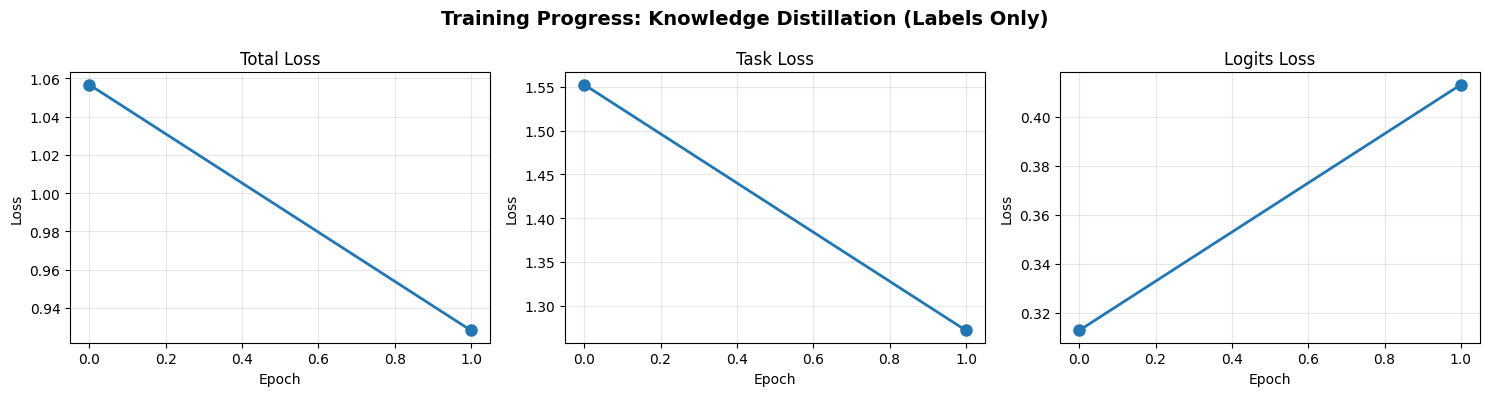

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
loss_keys = [("total", "Total Loss"), ("task", "Task Loss"), ("logits", "Logits Loss")]
for idx, (key, title) in enumerate(loss_keys):
    axes[idx].plot(stats['loss_history'][key], marker='o', linewidth=2, markersize=8)
    axes[idx].set_title(title)
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('Loss')
    axes[idx].grid(True, alpha=0.3)
plt.suptitle('Training Progress: Knowledge Distillation (Labels Only)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Final lm_eval Benchmarks

In [9]:
trained_student.eval()
print("Running lm_eval benchmarks...")
print(f"Tasks: {BENCHMARK_TASKS}")
print(f"Rows per task (limit): {LIMIT_BENCHMARK}")
print(f"Batch size: {LMEVAL_BATCH_SIZE}")

student_bench_raw = model_evaluation(
    trained_student,
    tokenizer,
    BENCHMARK_TASKS,
    limit=LIMIT_BENCHMARK,
    device=str(device),
    batch_size=LMEVAL_BATCH_SIZE,
)

def extract_acc(results, task):
    r = results.get(task, {})
    for key in ("accuracy", "acc_norm", "acc"):
        if key in r:
            return float(r[key]) * 100
    return 0.0

student_scores = {task: extract_acc(student_bench_raw, task) for task in BENCHMARK_TASKS}

print("\nBenchmark results (student):")
print(f"{'Task':<20} {'Score':>10}")
print('-' * 32)
for task in BENCHMARK_TASKS:
    print(f"{task:<20} {student_scores[task]:>9.1f}%")

avg_student = sum(student_scores.values()) / len(student_scores)
print('-' * 32)
print(f"{'AVERAGE':<20} {avg_student:>9.1f}%")

Running lm_eval benchmarks...
Tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']
Rows per task (limit): 400
Batch size: auto
Starting lm-eval on model 'oopere/llama-3.2-3b-attn-drop-3' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']

Tasks grouped by few-shot: {0: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']} (limit=400)
Task-level few-shot config: {'arc_easy': 0, 'winogrande': 0, 'hellaswag': 0, 'lambada_openai': 0, 'piqa': 0}

Evaluating 5 task(s) with 0-shot learning...


README.md: 0.00B [00:00, ?B/s]

ARC-Easy/train-00000-of-00001.parquet:   0%|          | 0.00/331k [00:00<?, ?B/s]

ARC-Easy/test-00000-of-00001.parquet:   0%|          | 0.00/346k [00:00<?, ?B/s]

ARC-Easy/validation-00000-of-00001.parqu(…):   0%|          | 0.00/86.1k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/3084 [00:00<?, ? examples/s]

Running loglikelihood requests: 100%|██████████| 5198/5198 [02:44<00:00, 31.57it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:00<00:00, 157.75it/s]



Benchmark results (student):
Task                      Score
--------------------------------
arc_easy                  75.0%
winogrande                69.0%
hellaswag                 50.0%
lambada_openai            64.2%
piqa                      76.2%
--------------------------------
AVERAGE                   66.9%


In [10]:
student_bench_raw

{'arc_easy': {'accuracy': '0.7500', 'acc_norm': '0.6975'},
 'hellaswag': {'accuracy': '0.5000', 'acc_norm': '0.6525'},
 'lambada_openai': {'perplexity': '5.27', 'accuracy': '0.6425'},
 'piqa': {'accuracy': '0.7625', 'acc_norm': '0.7775'},
 'winogrande': {'accuracy': '0.6900'}}

{'arc_easy': {'accuracy': '0.7500', 'acc_norm': '0.6975'},
 'hellaswag': {'accuracy': '0.5000', 'acc_norm': '0.6525'},
 'lambada_openai': {'perplexity': '5.27', 'accuracy': '0.6425'},
 'piqa': {'accuracy': '0.7625', 'acc_norm': '0.7775'},
 'winogrande': {'accuracy': '0.6900'}}